In [80]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch import nn
from typing import Any, Dict, Optional, Union
from tqdm import tqdm
import json
import numpy as np
from sklearn.preprocessing import StandardScaler


from causalflows.flows import CausalMAF, CausalNSF
from causalflows.scms import SCM, CausalEquations

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Import our Knowledge graphs

#NOTE we need to put 1 in the diagonal of the adjacency matrix

In [96]:
with open("new_ordered_graphs.json", 'r', encoding='utf-8') as f:
    loaded_graphs = json.load(f)

#loaded_graphs=loaded_graphs[0:2]
selected_graph = loaded_graphs[0]  
variables = selected_graph['variables']
adjacency_matrix = selected_graph['adjacency_matrix']

adj_array = np.array(adjacency_matrix)
# Add ones to the diagonal
np.fill_diagonal(adj_array, 1)

# Convert to torch tensor (boolean)
adjacency = torch.tensor(adj_array, dtype=torch.bool)
adjacency

tensor([[ True, False, False, False, False, False, False],
        [ True,  True, False, False, False, False, False],
        [False, False,  True, False, False, False, False],
        [False,  True, False,  True, False, False, False],
        [ True,  True, False,  True,  True, False, False],
        [ True,  True, False,  True, False,  True, False],
        [ True,  True,  True,  True,  True,  True,  True]])

Import ground truth graph - global order

In [112]:
# Load ground truth model FIRST
checkpoint_gt = torch.load('new_saved_models_final/flow_ground_truth.pt', weights_only=False)
scaler_gt = checkpoint_gt['scaler']  # Usar el scaler guardado
gt_variables = checkpoint_gt['variables']

## Import our diabetes dataset

In [113]:
data_df = pd.read_csv("TFM_dataset.csv")

# Drop patient ID column 
data_df = data_df.drop(columns=['randid'])

data_df = data_df[gt_variables]

# Fill missing BMI values with mode
bmi_mode = data_df['bmi'].mode()[0]
data_df['bmi'] = data_df['bmi'].fillna(bmi_mode)


In [114]:
diabetes_idx = variables.index('diabetes mellitus')

total_diabetes = (data_df['diabetes mellitus'] == 1).sum()
total_no_diabetes = (data_df['diabetes mellitus'] == 0).sum()
print(f" Total dataset:")
print(f"   Diabetes = 1: {total_diabetes} ({total_diabetes/len(data_df)*100:.1f}%)")
print(f"   Diabetes = 0: {total_no_diabetes} ({total_no_diabetes/len(data_df)*100:.1f}%)")

 Total dataset:
   Diabetes = 1: 121 (2.7%)
   Diabetes = 0: 4313 (97.3%)


In [115]:
# Identify binary variables
binary_vars = []
for col in data_df.columns:
    unique_vals = sorted(data_df[col].unique())
    if len(unique_vals) == 2 and set(unique_vals).issubset({0.0, 1.0}):
        binary_vars.append(col)
        prop = (data_df[col] == 1).mean()
        print(f"Binary variable: {col:40s}: {prop:.1%}")

continuous_vars = [col for col in data_df.columns if col not in binary_vars]

# Usar el scaler del modelo cargado (después de cargar el modelo)

# Prepare data with LOADED scaler
data_normalized = data_df.copy()
np.random.seed(42)

# Normalize only continuous variables using LOADED scaler
if len(continuous_vars) > 0:
    continuous_indices = [data_df.columns.get_loc(c) for c in continuous_vars]
    # TRANSFORM (no fit_transform) con el scaler cargado
    data_normalized.iloc[:, continuous_indices] = scaler_gt.transform(
        data_df.iloc[:, continuous_indices]
    )

# Add noise to binary variables AFTER normalization
for col in binary_vars:
    noise_std = 0.03 if (data_df[col] == 1).mean() < 0.05 else 0.05
    noise = np.random.normal(0, noise_std, size=len(data_df))
    data_normalized[col] = data_df[col].astype(float) + noise

# STRATIFIED SPLIT
diabetes_labels = data_df['diabetes mellitus'].values

train_idx, test_idx = train_test_split(
    np.arange(len(data_normalized)),
    test_size=0.1,
    stratify=diabetes_labels,
    random_state=42
)

# Tensors
data_tensor = torch.tensor(data_normalized.values, dtype=torch.float32)

Binary variable: diabetes mellitus                       : 2.7%
Binary variable: cardiac ischemia                        : 16.5%
Binary variable: major acute cardiovascular event        : 26.1%


/tmp/ipykernel_1336/505219346.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.26386182 -0.46139399 -0.23211746 ...  0.22643559 -1.14922356
 -1.26386182]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_normalized.iloc[:, continuous_indices] = scaler_gt.transform(
/tmp/ipykernel_1336/505219346.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.08402598 -0.18519266 -0.26690478 ... -0.02176842  1.20391338
  0.22336794]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_normalized.iloc[:, continuous_indices] = scaler_gt.transform(
/tmp/ipykernel_1336/505219346.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.20488508 -0.5403975  -0.2303033  ...  0.03549173  0.3455859

In [116]:
train_data = data_tensor[train_idx]
test_data = data_tensor[test_idx]

features = len(variables)



In [117]:
# Load ground truth model
flow_gt = CausalNSF(
    checkpoint_gt['features'],
    0,
    adjacency=checkpoint_gt['adjacency'],
    hidden_features=checkpoint_gt['config']['hidden_dims']
)
flow_gt.load_state_dict(checkpoint_gt['model_state_dict'])
flow_gt.eval()

CausalNSF(
  (transform): MaskedAutoregressiveTransform(
    (base): MonotonicRQSTransform(bins=8)
    (passes): 5
    (hyper): MaskedMLP(
      (0): MaskedLinear(in_features=7, out_features=32, bias=True)
      (1): ReLU()
      (2): MaskedLinear(in_features=32, out_features=32, bias=True)
      (3): ReLU()
      (4): MaskedLinear(in_features=32, out_features=161, bias=True)
    )
  )
  (base): UnconditionalDistribution(DiagNormal(loc: torch.Size([7]), scale: torch.Size([7])))
)

In [118]:
# len(loaded_graphs)
loaded_graphs=loaded_graphs[0:2]

In [126]:
len(loaded_graphs)

2

In [127]:
# Load all models
loaded_models = []

for graph_idx in range(len(loaded_graphs)):
    # Load selected graph model
    checkpoint_selected = torch.load(
        f'saved_models/flow_selected_graph_{graph_idx}.pt',
        map_location=torch.device('cpu'),
        weights_only=False  
    )
    flow_selected = CausalNSF(
        checkpoint_selected['features'],
        0,
        adjacency=checkpoint_selected['adjacency'],
        hidden_features=checkpoint_selected['config']['hidden_dims']
    )
    flow_selected.load_state_dict(checkpoint_selected['model_state_dict'])
    flow_selected.eval()
    
    loaded_models.append({
        'flow_selected': flow_selected,
        'variables': checkpoint_selected['variables'],
        'scaler': checkpoint_selected['scaler'], 
    })

print(f"Loaded {len(loaded_models)} model pairs")

Loaded 2 model pairs


In [120]:
def create_df(tensors_dict, var_order=None):
    """
    Create DataFrame from tensors or numpy arrays.
    
    Args:
        tensors_dict: dict of {name: tensor or numpy array}
        var_order: list of variable names (if None, uses global variables)
    """
    if var_order is None:
        var_order = variables
        
    df_list = []
    for i, (k, x) in enumerate(tensors_dict.items()):
        # Handle both torch tensors and numpy arrays
        if isinstance(x, torch.Tensor):
            x_np = x.numpy()
        else:
            x_np = x  # Already numpy array
            
        df = pd.DataFrame(x_np, columns=var_order)
        df['name'] = k
        df_list.append(df)

    df = pd.concat(df_list)
    return df

def plot_data(tensors_dict, var_order=None):
    """Plot data with consistent variable ordering."""
    df = create_df(tensors_dict, var_order)
    g = sns.PairGrid(df, diag_sharey=False, hue='name')
    g.map_upper(sns.scatterplot, s=15, alpha=0.5)
    g.map_lower(sns.kdeplot, common_norm=False)
    g.map_diag(sns.kdeplot, lw=2, common_norm=False)
    g.add_legend()
    plt.show()


gen_data new samples created by the model

**Plot comparing observational distribution and the flow distribution**

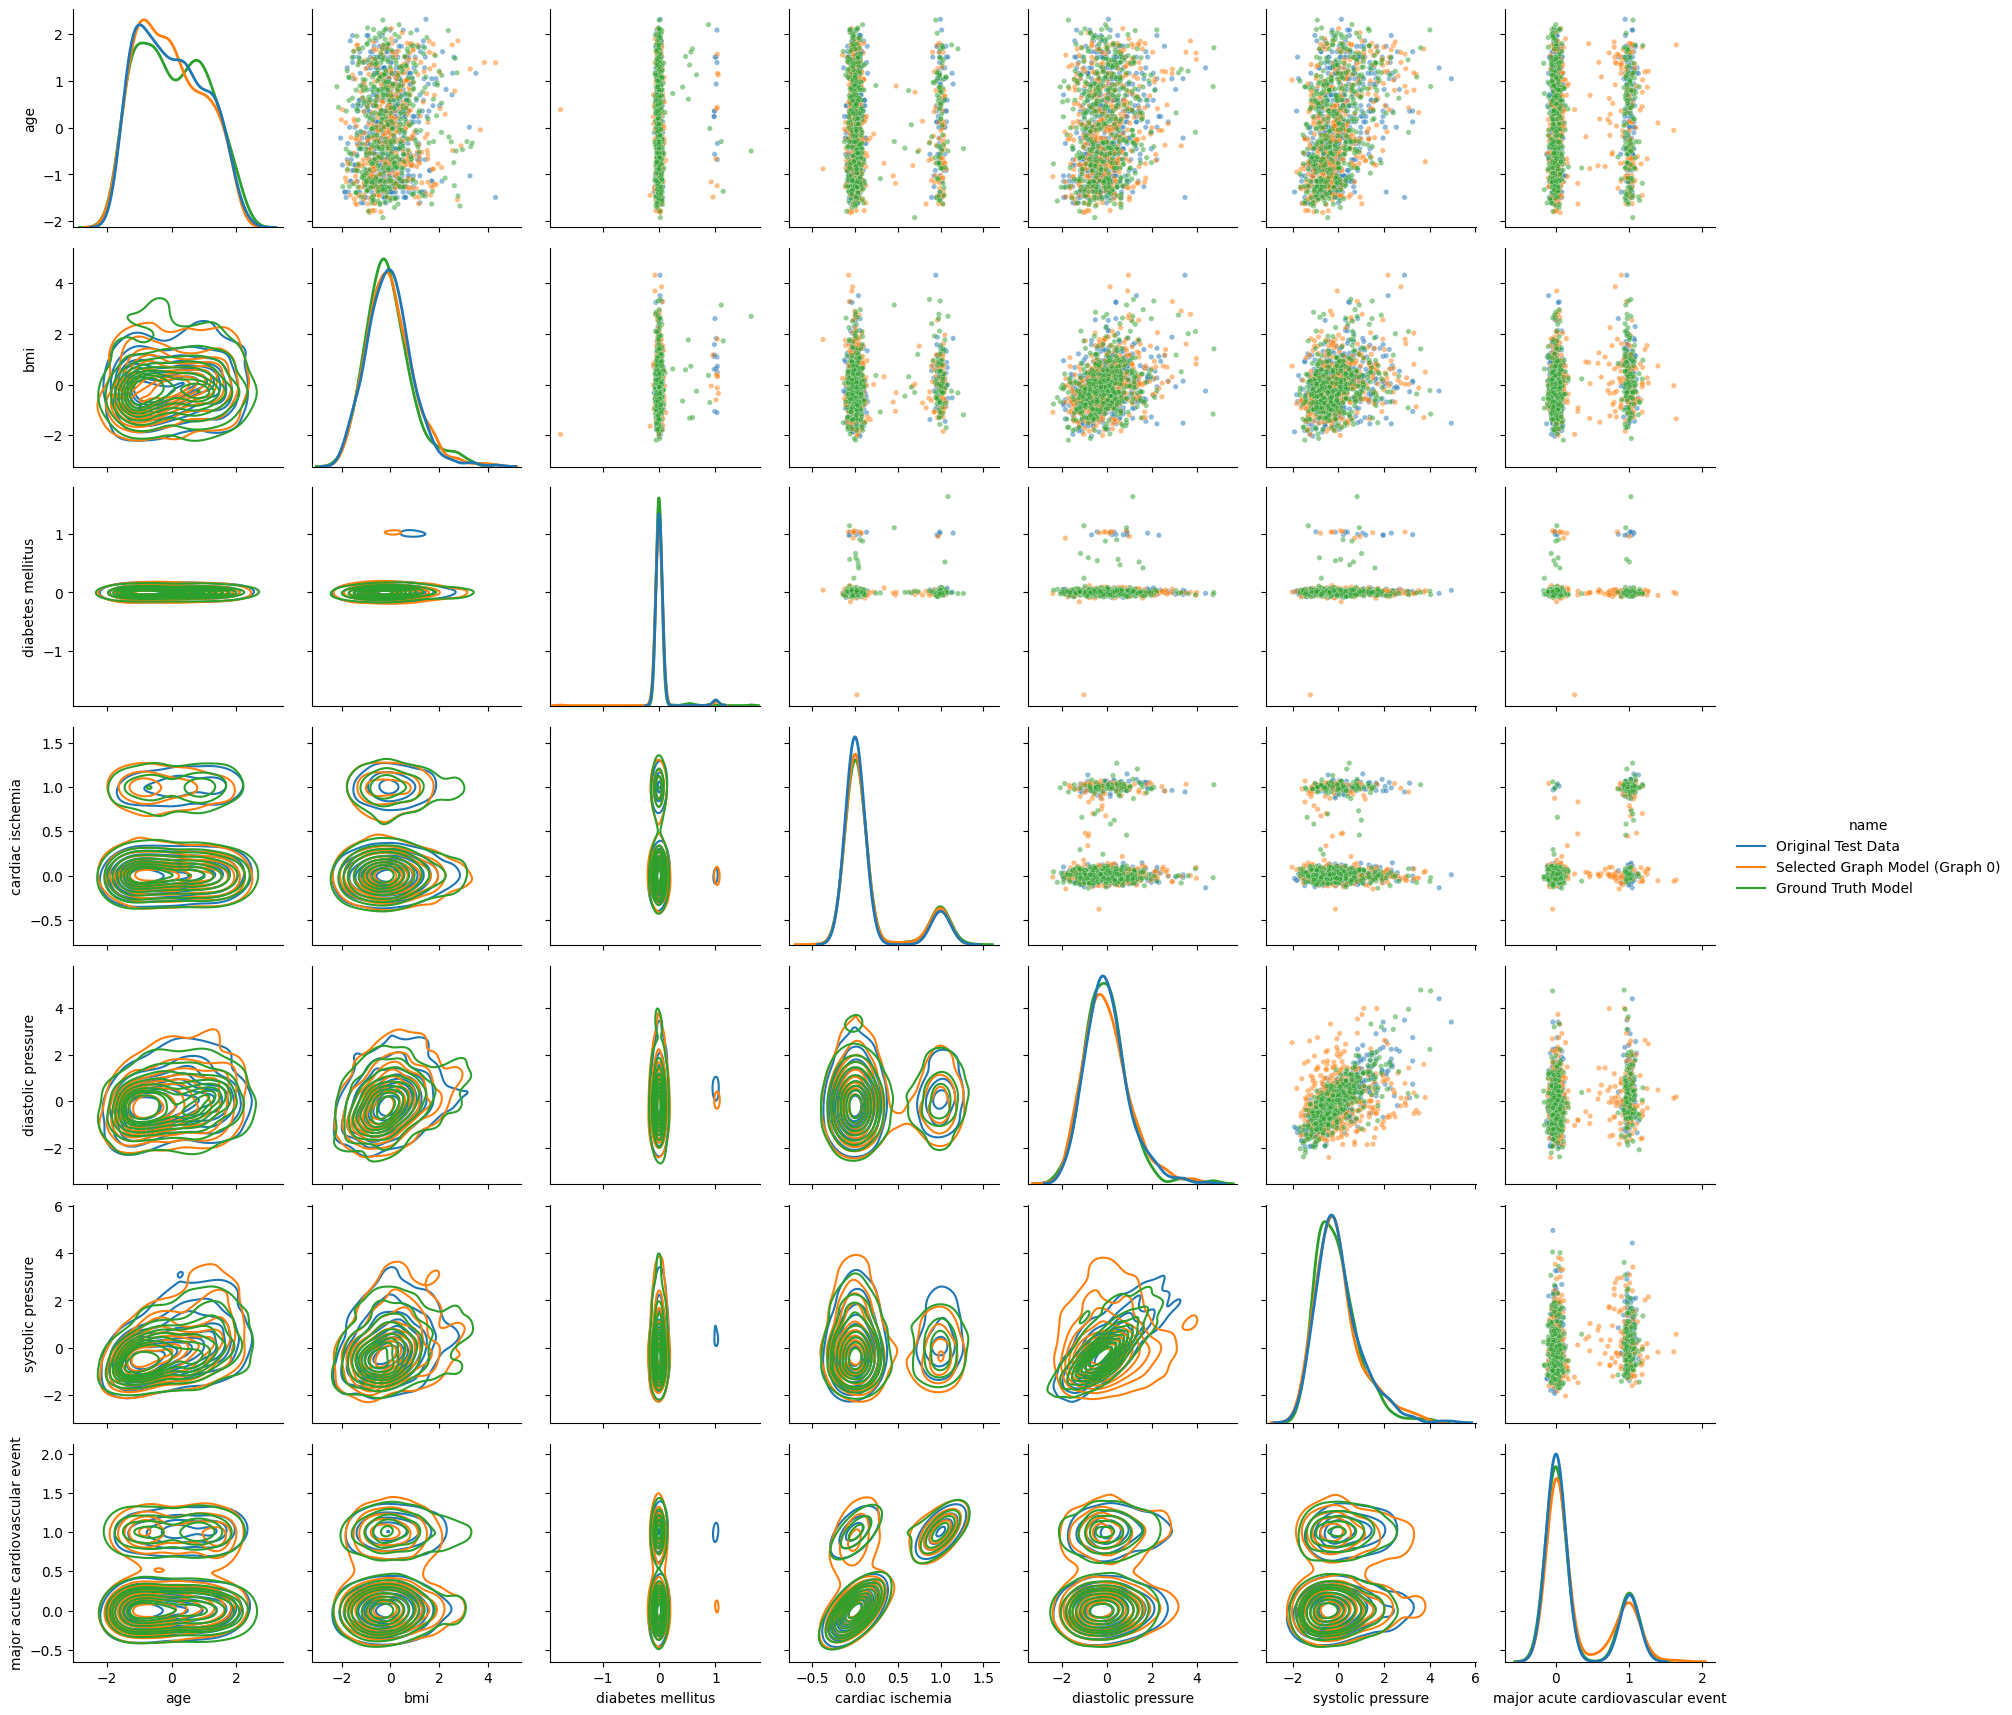

In [106]:
test_size= len(test_data)
model_idx = 0
flow_prueba = loaded_models[model_idx]
flow_selected = flow_prueba['flow_selected']
variables_selected = flow_prueba['variables']  # Variables del grafo seleccionado
scaler_selected = flow_prueba['scaler']

# Get ground truth variable order
gt_vars = checkpoint_gt['variables']

# Generate samples
gen_data_selected = flow_selected().sample([test_size]).numpy()
gen_data_gt = flow_gt().sample([test_size]).numpy()

# ✅ test_data YA está en orden GT (porque data_df = data_df[gt_variables])
# Solo necesitas reordenar gen_data_selected desde Graph 0 order → GT order
reorder_indices = [variables_selected.index(var) for var in gt_vars]
gen_data_selected_reordered = gen_data_selected[:, reorder_indices]

# Convert to tensors
gen_data_selected_reordered = torch.tensor(gen_data_selected_reordered)
gen_data_gt = torch.tensor(gen_data_gt)

# Plot with GT variable order
plot_data({
    'Original Test Data': test_data,  # Ya está en orden GT, no necesita reordenamiento
    'Selected Graph Model (Graph 0)': gen_data_selected_reordered,
    'Ground Truth Model': gen_data_gt
}, var_order=gt_vars)

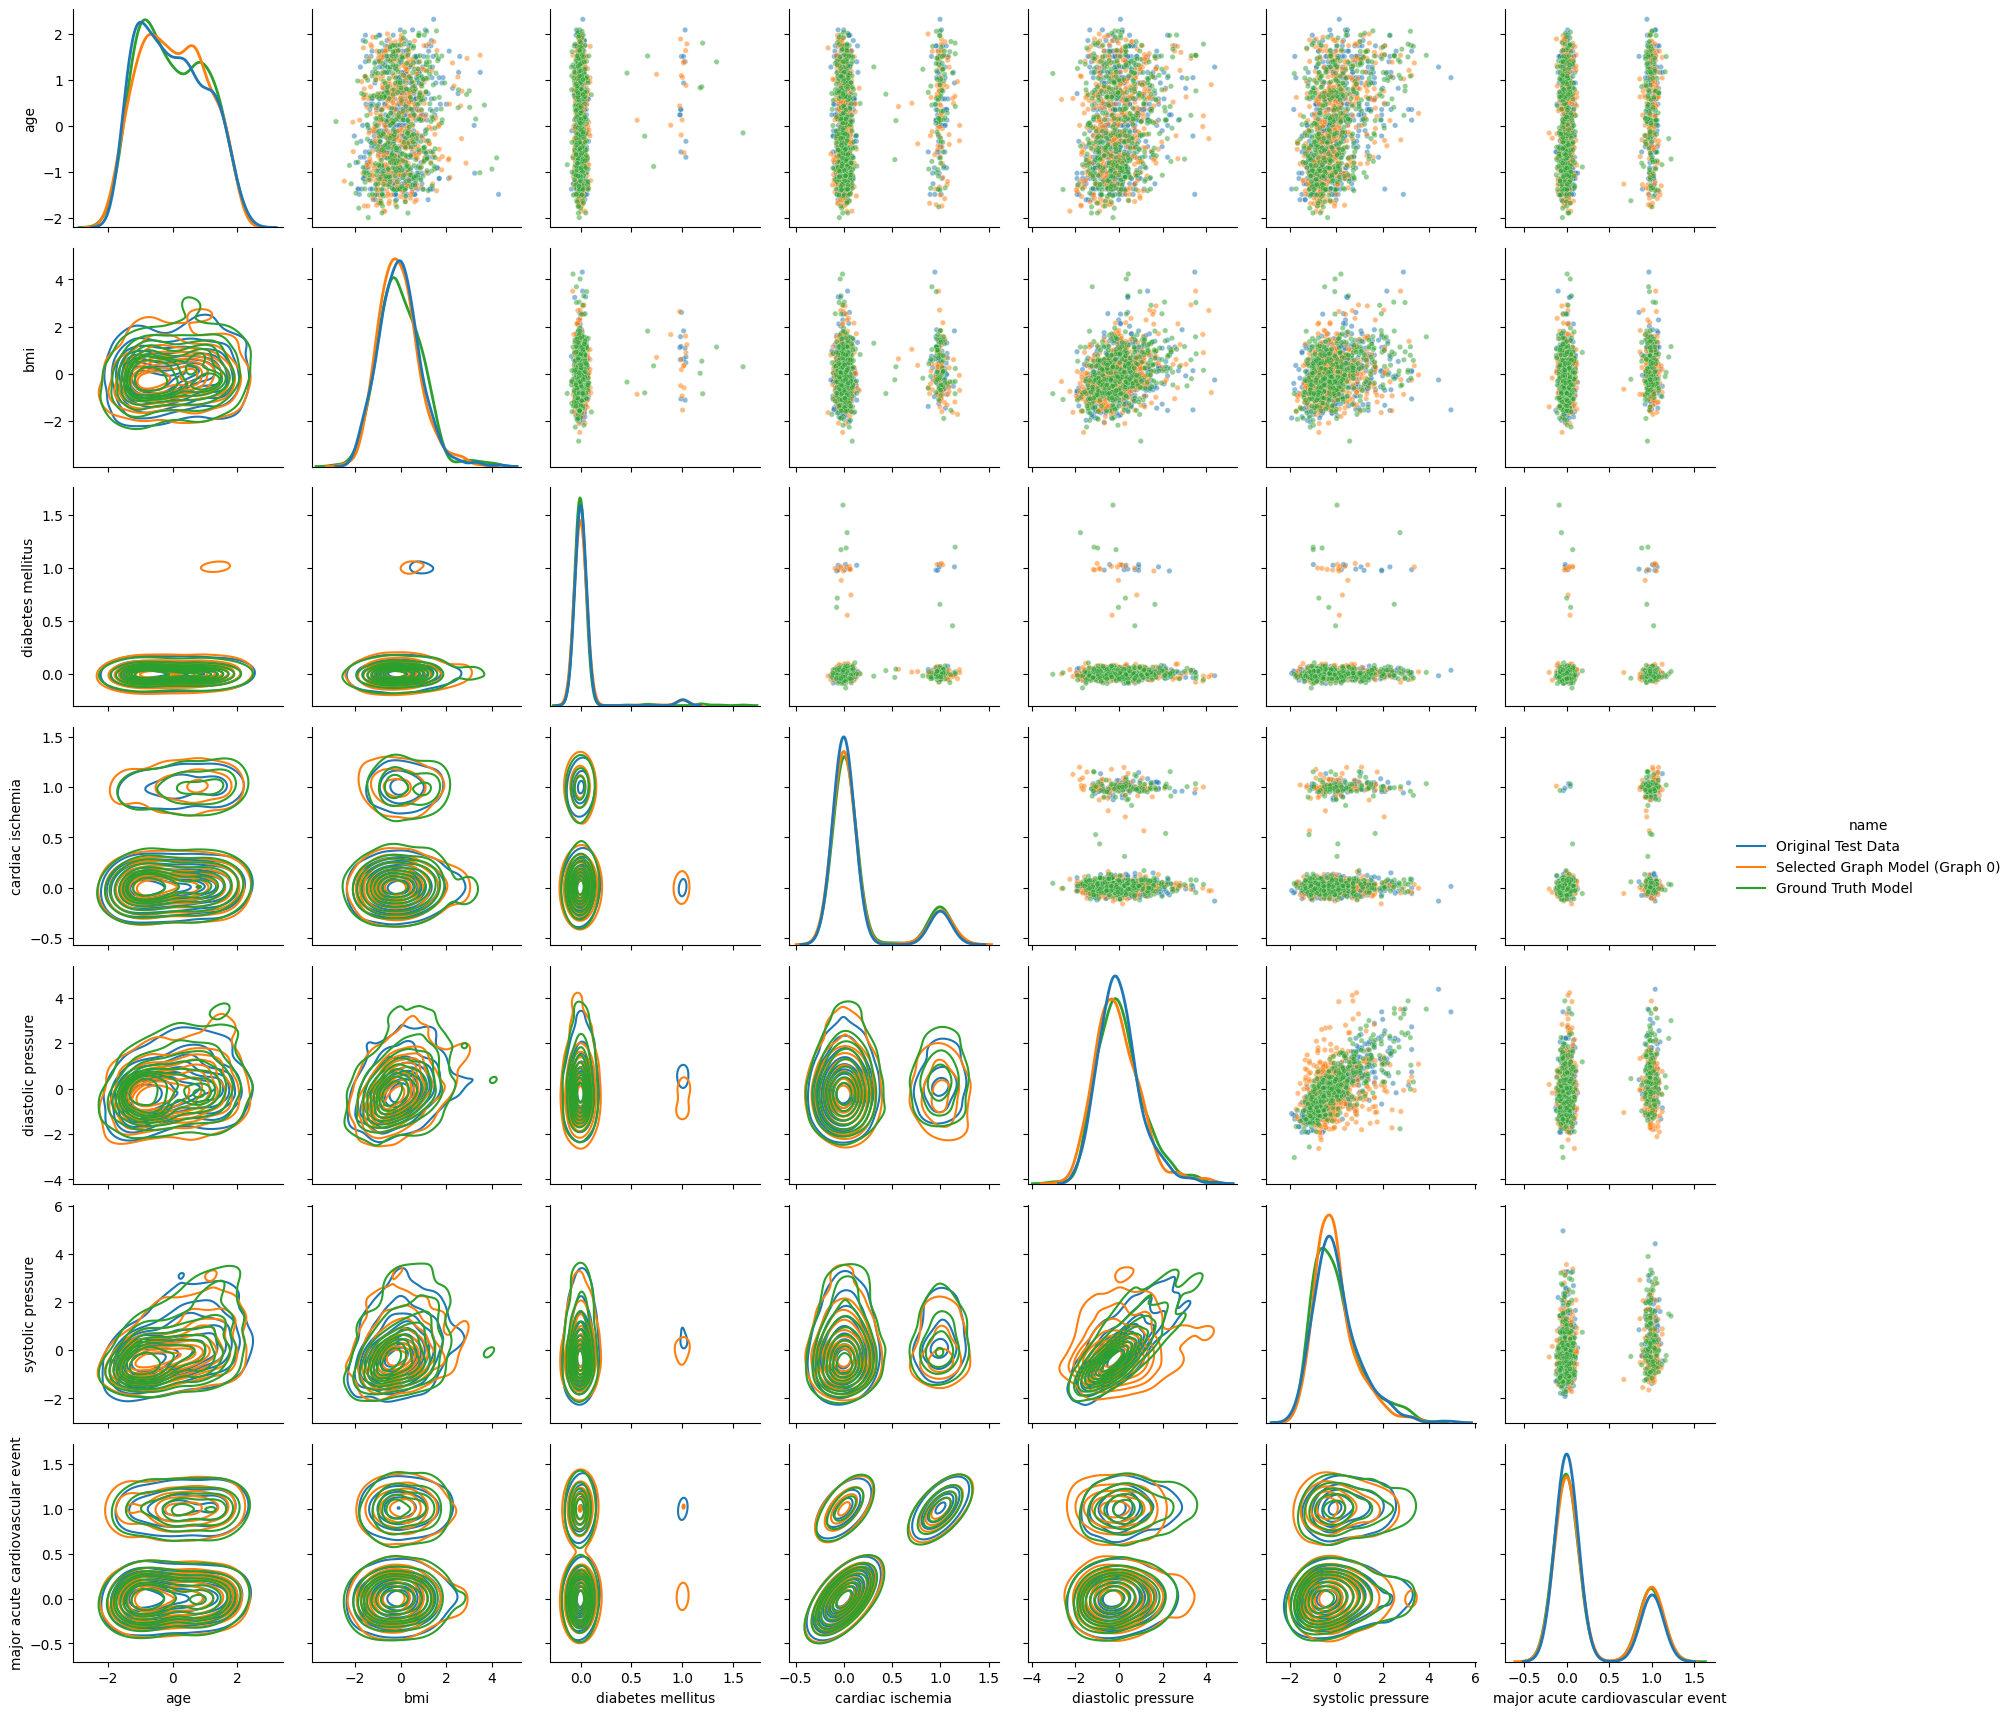

In [107]:
test_size= len(test_data)
model_idx = 1
flow_prueba = loaded_models[model_idx]
flow_selected = flow_prueba['flow_selected']
variables_selected = flow_prueba['variables']  # Variables del grafo seleccionado
scaler_selected = flow_prueba['scaler']

# Get ground truth variable order
gt_vars = checkpoint_gt['variables']

# Generate samples
gen_data_selected = flow_selected().sample([test_size]).numpy()
gen_data_gt = flow_gt().sample([test_size]).numpy()

reorder_indices = [variables_selected.index(var) for var in gt_vars]
gen_data_selected_reordered = gen_data_selected[:, reorder_indices]

# Convert to tensors
gen_data_selected_reordered = torch.tensor(gen_data_selected_reordered)
gen_data_gt = torch.tensor(gen_data_gt)

# Plot with GT variable order
plot_data({
    'Original Test Data': test_data,  # Ya está en orden GT, no necesita reordenamiento
    'Selected Graph Model (Graph 0)': gen_data_selected_reordered,
    'Ground Truth Model': gen_data_gt
}, var_order=gt_vars)

# Interventions

Choosing one variable for instance bmi and see how it changes from not having obesity to having obesity

# intervention bmi, outcome systolic pressure

In [128]:
scaler= scaler_gt
bmi_mean = scaler.mean_[1]
bmi_std = np.sqrt(scaler.var_[1])


In [129]:
intervention_var = 'bmi'  
intervention_index = gt_variables.index(intervention_var)

intervention_values = [24.0, 30.0]  # BMI low vs high, obesity vs non obesity
intervention_values = [float((val - bmi_mean) / bmi_std) for val in intervention_values]
intervention_values

[-0.4571423021848473, 0.9964617408493066]

problema que intervention values no estaba normalizado, tengo que normalizar porque mi modelo entiende en el rango normalizado, 
pero luego tengo que desnormalizar, despues de hacer la intervencion y generar las muestras, para ver los resultados en el rango original, la mean debe dar

ACLARAR INDICES DE VARIABLES CONTINUAS PARA NORMALIZAR Y DESNORMALIZAR 
mirar las que entren y salgan de mi modelo

tiene que haber algo de mapeo entre indice de variables que son las del grafo e indices del dataframe que yo meto
los indices de las variables del grafo van a cambiar porque mi grafo cambia

automatizar 


# Outcome in systolic pressure

In [130]:
outcome_var = 'systolic pressure'
outcome_index = gt_variables.index(outcome_var)

continuous_indices_in_data = [data_df.columns.get_loc(c) for c in continuous_vars] if len(continuous_vars) > 0 else []

# Selected graph ATE
samples_0_selected =    flow_selected().sample_interventional(
    index=intervention_index,
    value=intervention_values[0],
    sample_shape=(test_size,),
).numpy()

samples_1_selected = flow_selected().sample_interventional(
    index=intervention_index,
    value=intervention_values[1],
    sample_shape=(test_size,),
).numpy()

samples_0_selected_denorm = samples_0_selected.copy()
samples_1_selected_denorm = samples_1_selected.copy()

if len(continuous_indices_in_data) > 0:

    samples_0_selected_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_0_selected[:, continuous_indices_in_data]
    )
    samples_1_selected_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_1_selected[:, continuous_indices_in_data]
    )

if outcome_var in continuous_vars:
    mean_0_selected = samples_0_selected_denorm[:, outcome_index].mean()
    mean_1_selected = samples_1_selected_denorm[:, outcome_index].mean()
else:
    mean_0_selected = samples_0_selected[:, outcome_index].clip(0, 1).round().mean()
    mean_1_selected = samples_1_selected[:, outcome_index].clip(0, 1).round().mean()

ate_selected = mean_1_selected - mean_0_selected

# Ground truth ATE
samples_0_gt = flow_gt().sample_interventional(
    index=intervention_index,
    value=intervention_values[0],
    sample_shape=(test_size,),
).numpy()

samples_1_gt = flow_gt().sample_interventional(
    index=intervention_index,
    value=intervention_values[1],
    sample_shape=(test_size,),
).numpy()

samples_0_gt_denorm = samples_0_gt.copy()
samples_1_gt_denorm = samples_1_gt.copy()

if len(continuous_indices_in_data) > 0:
    samples_0_gt_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_0_gt[:, continuous_indices_in_data]
    )
    samples_1_gt_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_1_gt[:, continuous_indices_in_data]
    )

if outcome_var in continuous_vars:
    mean_0_gt = samples_0_gt_denorm[:, outcome_index].mean()
    mean_1_gt = samples_1_gt_denorm[:, outcome_index].mean()
else:
    mean_0_gt = samples_0_gt[:, outcome_index].clip(0, 1).round().mean()
    mean_1_gt = samples_1_gt[:, outcome_index].clip(0, 1).round().mean()

ate_gt = mean_1_gt - mean_0_gt


print(f"\nSelected Graph:")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_selected:.2f}")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_selected:.2f}")
print(f"   ATE = {ate_selected:+.2f}")

print(f"\nGround Truth Graph:")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_gt:.2f}")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_gt:.2f}")
print(f"   ATE = {ate_gt:+.2f}")


print(f"\nDifference ATE:")
if outcome_var in continuous_vars:
    print(f"   ATE_selected - ATE_gt= {abs(ate_selected - ate_gt):.2f}")
else:
    print(f"   ATE_selected - ATE_gt = {abs(ate_selected - ate_gt):.1%}")


Selected Graph:
   E[systolic pressure | do(bmi=-0.46)] = 138.44
   E[systolic pressure | do(bmi=1.00)] = 140.77
   ATE = +2.33

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.46)] = 130.52
   E[systolic pressure | do(bmi=1.00)] = 137.45
   ATE = +6.94

Difference ATE:
   ATE_selected - ATE_gt= 4.61


# Intervention in age and see diabetes mellitus outcome 

In [69]:
scaler = scaler_gt

# Encuentra el índice de 'age' en continuous_vars (orden del scaler)
age_scaler_index = continuous_vars.index('age')

# Obtén media y std del scaler
age_mean = scaler.mean_[age_scaler_index]
age_std = np.sqrt(scaler.var_[age_scaler_index])

# Define la variable de intervención
intervention_var = 'age'  
intervention_index = gt_variables.index(intervention_var)

# Normaliza los valores de intervención
intervention_values = [40.0, 70.0]  # Age young vs old
intervention_values = [float((val - age_mean) / age_std) for val in intervention_values]
intervention_values

[-1.1440591224011503, 2.313775156797255]

In [72]:
outcome_var = 'diabetes mellitus'
outcome_index = gt_variables.index(outcome_var)

continuous_indices_in_data = [data_df.columns.get_loc(c) for c in continuous_vars] if len(continuous_vars) > 0 else []

# Selected graph ATE
samples_0_selected = flow_selected().sample_interventional(
    index=intervention_index,
    value=intervention_values[0],
    sample_shape=(test_size,),
).numpy()

samples_1_selected = flow_selected().sample_interventional(
    index=intervention_index,
    value=intervention_values[1],
    sample_shape=(test_size,),
).numpy()

samples_0_selected_denorm = samples_0_selected.copy()
samples_1_selected_denorm = samples_1_selected.copy()

if len(continuous_indices_in_data) > 0:
    samples_0_selected_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_0_selected[:, continuous_indices_in_data]
    )
    samples_1_selected_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_1_selected[:, continuous_indices_in_data]
    )

if outcome_var in continuous_vars:
    mean_0_selected = samples_0_selected_denorm[:, outcome_index].mean()
    mean_1_selected = samples_1_selected_denorm[:, outcome_index].mean()
else:
    mean_0_selected = samples_0_selected[:, outcome_index].clip(0, 1).round().mean()
    mean_1_selected = samples_1_selected[:, outcome_index].clip(0, 1).round().mean()

ate_selected = mean_1_selected - mean_0_selected

# Ground truth ATE
samples_0_gt = flow_gt().sample_interventional(
    index=intervention_index,
    value=intervention_values[0],
    sample_shape=(test_size,),
).numpy()

samples_1_gt = flow_gt().sample_interventional(
    index=intervention_index,
    value=intervention_values[1],
    sample_shape=(test_size,),
).numpy()

samples_0_gt_denorm = samples_0_gt.copy()
samples_1_gt_denorm = samples_1_gt.copy()

if len(continuous_indices_in_data) > 0:
    samples_0_gt_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_0_gt[:, continuous_indices_in_data]
    )
    samples_1_gt_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_1_gt[:, continuous_indices_in_data]
    )

if outcome_var in continuous_vars:
    mean_0_gt = samples_0_gt_denorm[:, outcome_index].mean()
    mean_1_gt = samples_1_gt_denorm[:, outcome_index].mean()
else:
    mean_0_gt = samples_0_gt[:, outcome_index].clip(0, 1).round().mean()
    mean_1_gt = samples_1_gt[:, outcome_index].clip(0, 1).round().mean()

ate_gt = mean_1_gt - mean_0_gt


print(f"\nSelected Graph:")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_selected:.2f}")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_selected:.2f}")
print(f"   ATE = {ate_selected:+.2f}")

print(f"\nGround Truth Graph:")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_gt:.2f}")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_gt:.2f}")
print(f"   ATE = {ate_gt:+.2f}")

print(f"\nDifference ATE:")
print(f"   ATE_selected - ATE_gt = {abs(ate_selected - ate_gt):.2f}")


Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.09
   E[diabetes mellitus | do(age=2.31)] = 0.31
   ATE = +0.22

Ground Truth Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.01
   E[diabetes mellitus | do(age=2.31)] = 0.06
   ATE = +0.05

Difference ATE:
   ATE_selected - ATE_gt = 0.17


intervention in systolic pressure see major acute cardiovascular event outcome

In [78]:
scaler = scaler_gt

# Encuentra el índice de 'systolic pressure' en continuous_vars (orden del scaler)
sysbp_scaler_index = continuous_vars.index('bmi')

# Obtén media y std del scaler
sysbp_mean = scaler.mean_[sysbp_scaler_index]
sysbp_std = np.sqrt(scaler.var_[sysbp_scaler_index])

# Define la variable de intervención
intervention_var = 'bmi'  
intervention_index = gt_variables.index(intervention_var)

# Normaliza los valores de intervención
intervention_values = [18.5, 33.0]  # BMI normal vs high
intervention_values = [float((val - sysbp_mean) / sysbp_std) for val in intervention_values]
intervention_values

[-1.7915232334637592, 1.7478025709673863]

In [79]:
outcome_var = 'diabetes mellitus'
outcome_index = gt_variables.index(outcome_var)

continuous_indices_in_data = [data_df.columns.get_loc(c) for c in continuous_vars] if len(continuous_vars) > 0 else []

# Selected graph ATE
samples_0_selected = flow_selected().sample_interventional(
    index=intervention_index,
    value=intervention_values[0],
    sample_shape=(test_size,),
).numpy()

samples_1_selected = flow_selected().sample_interventional(
    index=intervention_index,
    value=intervention_values[1],
    sample_shape=(test_size,),
).numpy()

samples_0_selected_denorm = samples_0_selected.copy()
samples_1_selected_denorm = samples_1_selected.copy()

if len(continuous_indices_in_data) > 0:
    samples_0_selected_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_0_selected[:, continuous_indices_in_data]
    )
    samples_1_selected_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_1_selected[:, continuous_indices_in_data]
    )

if outcome_var in continuous_vars:
    mean_0_selected = samples_0_selected_denorm[:, outcome_index].mean()
    mean_1_selected = samples_1_selected_denorm[:, outcome_index].mean()
else:
    mean_0_selected = samples_0_selected[:, outcome_index].clip(0, 1).round().mean()
    mean_1_selected = samples_1_selected[:, outcome_index].clip(0, 1).round().mean()

ate_selected = mean_1_selected - mean_0_selected

# Ground truth ATE
samples_0_gt = flow_gt().sample_interventional(
    index=intervention_index,
    value=intervention_values[0],
    sample_shape=(test_size,),
).numpy()

samples_1_gt = flow_gt().sample_interventional(
    index=intervention_index,
    value=intervention_values[1],
    sample_shape=(test_size,),
).numpy()

samples_0_gt_denorm = samples_0_gt.copy()
samples_1_gt_denorm = samples_1_gt.copy()

if len(continuous_indices_in_data) > 0:
    samples_0_gt_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_0_gt[:, continuous_indices_in_data]
    )
    samples_1_gt_denorm[:, continuous_indices_in_data] = scaler.inverse_transform(
        samples_1_gt[:, continuous_indices_in_data]
    )

if outcome_var in continuous_vars:
    mean_0_gt = samples_0_gt_denorm[:, outcome_index].mean()
    mean_1_gt = samples_1_gt_denorm[:, outcome_index].mean()
else:
    mean_0_gt = samples_0_gt[:, outcome_index].clip(0, 1).round().mean()
    mean_1_gt = samples_1_gt[:, outcome_index].clip(0, 1).round().mean()

ate_gt = mean_1_gt - mean_0_gt


print(f"\nSelected Graph:")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_selected:.2f}")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_selected:.2f}")
print(f"   ATE = {ate_selected:+.2f}")

print(f"\nGround Truth Graph:")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_gt:.2f}")
print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_gt:.2f}")
print(f"   ATE = {ate_gt:+.2f}")

print(f"\nDifference ATE:")
print(f"   ATE_selected - ATE_gt = {abs(ate_selected - ate_gt):.2f}")


Selected Graph:
   E[diabetes mellitus | do(bmi=-1.79)] = 0.14
   E[diabetes mellitus | do(bmi=1.75)] = 0.21
   ATE = +0.07

Ground Truth Graph:
   E[diabetes mellitus | do(bmi=-1.79)] = 0.01
   E[diabetes mellitus | do(bmi=1.75)] = 0.05
   ATE = +0.05

Difference ATE:
   ATE_selected - ATE_gt = 0.02


Function

FINAL FUNCTION FOR INTERVENTIONS

In [78]:
def intervention_ate(
    flow_model,
    flow_gt,
    intervention_var,
    intervention_values,
    outcome_var,
    variables_selected,
    gt_variables,
    continuous_vars,
    scaler_selected,
    scaler_gt,
    test_size
):
    """
    Compute ATE for an intervention on a variable for a given model and ground truth.

    Args:
        flow_model: Trained CausalNSF model for selected graph.
        flow_gt: Trained CausalNSF model for ground truth graph.
        intervention_var: Variable name to intervene on.
        intervention_values: List of two values for intervention.
        outcome_var: Variable name for outcome.
        variables_selected: Variable order for selected graph.
        gt_variables: Variable order for ground truth.
        continuous_vars: List of continuous variable names.
        scaler_selected: Scaler for selected graph.
        scaler_gt: Scaler for ground truth graph.
        test_size: Number of samples to generate.

    Returns:
        Dictionary with means and ATEs for selected and ground truth models.
    """
    # Only use ground truth variables that are present in the selected graph
    gt_vars_in_selected = [var for var in gt_variables if var in variables_selected]
    if outcome_var not in gt_vars_in_selected:
        raise ValueError(f"Outcome variable '{outcome_var}' not in selected graph variables.")

    intervention_index_selected = variables_selected.index(intervention_var)
    continuous_indices_selected = [variables_selected.index(c) for c in continuous_vars if c in variables_selected]

    intervention_index_gt = gt_variables.index(intervention_var)
    continuous_indices_gt = [gt_variables.index(c) for c in continuous_vars if c in gt_variables]

    outcome_index_gt = gt_vars_in_selected.index(outcome_var)

    # Selected graph: generate samples in its variable order
    samples_0_selected = flow_model().sample_interventional(
        index=intervention_index_selected,
        value=intervention_values[0],
        sample_shape=(test_size,),
    ).numpy()
    samples_1_selected = flow_model().sample_interventional(
        index=intervention_index_selected,
        value=intervention_values[1],
        sample_shape=(test_size,),
    ).numpy()

    # Denormalize using the scaler of the selected model
    samples_0_selected_denorm = samples_0_selected.copy()
    samples_1_selected_denorm = samples_1_selected.copy()
    if len(continuous_indices_selected) > 0:
        samples_0_selected_denorm[:, continuous_indices_selected] = scaler_selected.inverse_transform(
            samples_0_selected[:, continuous_indices_selected]
        )
        samples_1_selected_denorm[:, continuous_indices_selected] = scaler_selected.inverse_transform(
            samples_1_selected[:, continuous_indices_selected]
        )

    # Reorder only the variables present in both selected and ground truth
    reorder_indices = [variables_selected.index(var) for var in gt_vars_in_selected]
    samples_0_selected_denorm_gt = samples_0_selected_denorm[:, reorder_indices]
    samples_1_selected_denorm_gt = samples_1_selected_denorm[:, reorder_indices]

    # Ground truth: generate samples in its variable order
    samples_0_gt = flow_gt().sample_interventional(
        index=intervention_index_gt,
        value=intervention_values[0],
        sample_shape=(test_size,),
    ).numpy()
    samples_1_gt = flow_gt().sample_interventional(
        index=intervention_index_gt,
        value=intervention_values[1],
        sample_shape=(test_size,),
    ).numpy()

    # Denormalize using the scaler of the ground truth model
    samples_0_gt_denorm = samples_0_gt.copy()
    samples_1_gt_denorm = samples_1_gt.copy()
    if len(continuous_indices_gt) > 0:
        samples_0_gt_denorm[:, continuous_indices_gt] = scaler_gt.inverse_transform(
            samples_0_gt[:, continuous_indices_gt]
        )
        samples_1_gt_denorm[:, continuous_indices_gt] = scaler_gt.inverse_transform(
            samples_1_gt[:, continuous_indices_gt]
        )

    # Calculate means and ATE in the ground truth order (only for present variables)
    if outcome_var in continuous_vars:
        mean_0_selected = samples_0_selected_denorm_gt[:, outcome_index_gt].mean()
        mean_1_selected = samples_1_selected_denorm_gt[:, outcome_index_gt].mean()
        mean_0_gt = samples_0_gt_denorm[:, gt_variables.index(outcome_var)].mean()
        mean_1_gt = samples_1_gt_denorm[:, gt_variables.index(outcome_var)].mean()
    else:
        mean_0_selected = samples_0_selected_denorm_gt[:, outcome_index_gt].clip(0, 1).round().mean()
        mean_1_selected = samples_1_selected_denorm_gt[:, outcome_index_gt].clip(0, 1).round().mean()
        mean_0_gt = samples_0_gt_denorm[:, gt_variables.index(outcome_var)].clip(0, 1).round().mean()
        mean_1_gt = samples_1_gt_denorm[:, gt_variables.index(outcome_var)].clip(0, 1).round().mean()

    ate_selected = mean_1_selected - mean_0_selected
    ate_gt = mean_1_gt - mean_0_gt

    print(f"\nSelected Graph:")
    print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_selected:.2f}")
    print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_selected:.2f}")
    print(f"   ATE = {ate_selected:+.2f}")

    print(f"\nGround Truth Graph:")
    print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_gt:.2f}")
    print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_gt:.2f}")
    print(f"   ATE = {ate_gt:+.2f}")

    print(f"\nDifference ATE:")
    if outcome_var in continuous_vars:
        print(f"   ATE_selected - ATE_gt= {abs(ate_selected - ate_gt):.2f}")
    else:
        print(f"   ATE_selected - ATE_gt = {abs(ate_selected - ate_gt):.1%}")

    return {
        "mean_0_selected": mean_0_selected,
        "mean_1_selected": mean_1_selected,
        "ate_selected": ate_selected,
        "mean_0_gt": mean_0_gt,
        "mean_1_gt": mean_1_gt,
        "ate_gt": ate_gt,
        "ate_diff": abs(ate_selected - ate_gt)
    }


In [ ]:
import scipy.stats as stats

ate_selected_list = []
ate_gt_list = []

for model_dict in loaded_models:
    flow_selected = model_dict['flow_selected']
    variables_selected = model_dict['variables']
    scaler_selected = model_dict['scaler']
    scaler_gt = checkpoint_gt['scaler']
    gt_variables = checkpoint_gt['variables']

    # Run intervention for each model using the new function
    result = intervention_ate(
        flow_model=flow_selected,
        flow_gt=flow_gt,
        intervention_var='bmi',
        intervention_values=intervention_values,
        outcome_var='systolic pressure',
        variables_selected=variables_selected,
        gt_variables=gt_variables,
        continuous_vars=continuous_vars,
        scaler_selected=scaler_selected,
        scaler_gt=scaler_gt,
        test_size=len(test_data)
    )
    ate_selected_list.append(result['ate_selected'])
    ate_gt_list.append(result['ate_gt'])

# Calculate mean and 95% confidence interval for selected graphs
ate_selected_array = np.array(ate_selected_list)
mean_ate_selected = ate_selected_array.mean()
conf_int_selected = stats.norm.interval(
    0.99,
    loc=mean_ate_selected,
    scale=stats.sem(ate_selected_array)
)

# Calculate mean and 95% confidence interval for ground truth
ate_gt_array = np.array(ate_gt_list)
mean_ate_gt = ate_gt_array.mean()
conf_int_gt = stats.norm.interval(
    0.99,
    loc=mean_ate_gt,
    scale=stats.sem(ate_gt_array)
)

print(f"\nMean ATE (selected graphs): {mean_ate_selected:.2f}")
print(f"95% Confidence Interval (selected): [{conf_int_selected[0]:.2f}, {conf_int_selected[1]:.2f}]")
print(f"\nMean ATE (ground truth): {mean_ate_gt:.2f}")
print(f"95% Confidence Interval (ground truth): [{conf_int_gt[0]:.2f}, {conf_int_gt[1]:.2f}]")



Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.30
   E[systolic pressure | do(bmi=1.02)] = 137.68
   ATE = +7.38

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 129.91
   E[systolic pressure | do(bmi=1.02)] = 138.43
   ATE = +8.51

Difference ATE:
   ATE_selected - ATE_gt= 1.13

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 129.57
   E[systolic pressure | do(bmi=1.02)] = 139.97
   ATE = +10.40

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.77
   E[systolic pressure | do(bmi=1.02)] = 139.02
   ATE = +8.25

Difference ATE:
   ATE_selected - ATE_gt= 2.16

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 129.62
   E[systolic pressure | do(bmi=1.02)] = 139.31
   ATE = +9.69

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 126.84
   E[systolic pressure | do(bmi=1.02)] = 138.52
   ATE = +11.68

Difference ATE:
   ATE_selected - ATE_gt= 1.99

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 132.98
  

In [ ]:
import scipy.stats as stats
import numpy as np

ate_selected_list = []
ate_gt_list = []

for model_dict in loaded_models:
    flow_selected = model_dict['flow_selected']
    variables_selected = model_dict['variables']
    scaler_selected = model_dict['scaler']
    scaler_gt = checkpoint_gt['scaler']
    gt_variables = checkpoint_gt['variables']

    # Run intervention for each model using the new function
    result = intervention_ate(
        flow_model=flow_selected,
        flow_gt=flow_gt,
        intervention_var='bmi',
        intervention_values=intervention_values,
        outcome_var='systolic pressure',
        variables_selected=variables_selected,
        gt_variables=gt_variables,
        continuous_vars=continuous_vars,
        scaler_selected=scaler_selected,
        scaler_gt=scaler_gt,
        test_size=len(test_data)
    )
    ate_selected_list.append(result['ate_selected'])
    ate_gt_list.append(result['ate_gt'])

# Bootstrap confidence interval function
def bootstrap_ci(data, n_bootstrap=1000, ci=0.99):
    means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (1-ci)/2*100)
    upper = np.percentile(means, (1+ci)/2*100)
    return lower, upper

# Calculate mean and bootstrap confidence interval for selected graphs
ate_selected_array = np.array(ate_selected_list)
mean_ate_selected = ate_selected_array.mean()
conf_int_selected = bootstrap_ci(ate_selected_array, n_bootstrap=1000, ci=0.95)

# Calculate mean and bootstrap confidence interval for ground truth
ate_gt_array = np.array(ate_gt_list)
mean_ate_gt = ate_gt_array.mean()
conf_int_gt = bootstrap_ci(ate_gt_array, n_bootstrap=1000, ci=0.95)

print(f"\nMean ATE (selected graphs): {mean_ate_selected:.2f}")
print(f"Bootstrap 99% Confidence Interval (selected): [{conf_int_selected[0]:.2f}, {conf_int_selected[1]:.2f}]")
print(f"\nMean ATE (ground truth): {mean_ate_gt:.2f}")
print(f"Bootstrap 99% Confidence Interval (ground truth): [{conf_int_gt[0]:.2f}, {conf_int_gt[1]:.2f}]")


Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 132.14
   E[systolic pressure | do(bmi=1.02)] = 140.31
   ATE = +8.17

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.91
   E[systolic pressure | do(bmi=1.02)] = 139.27
   ATE = +8.36

Difference ATE:
   ATE_selected - ATE_gt= 0.19

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 131.55
   E[systolic pressure | do(bmi=1.02)] = 138.59
   ATE = +7.04

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 129.19
   E[systolic pressure | do(bmi=1.02)] = 138.59
   ATE = +9.40

Difference ATE:
   ATE_selected - ATE_gt= 2.36

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.18
   E[systolic pressure | do(bmi=1.02)] = 139.00
   ATE = +8.81

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.06
   E[systolic pressure | do(bmi=1.02)] = 138.50
   ATE = +8.44

Difference ATE:
   ATE_selected - ATE_gt= 0.37

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 133.31
   E

coverage --> how to measure it?

tengo que medir cuantas veces el valor cae dentro del intervalo

Let's plot it to see if it is a normal distribution

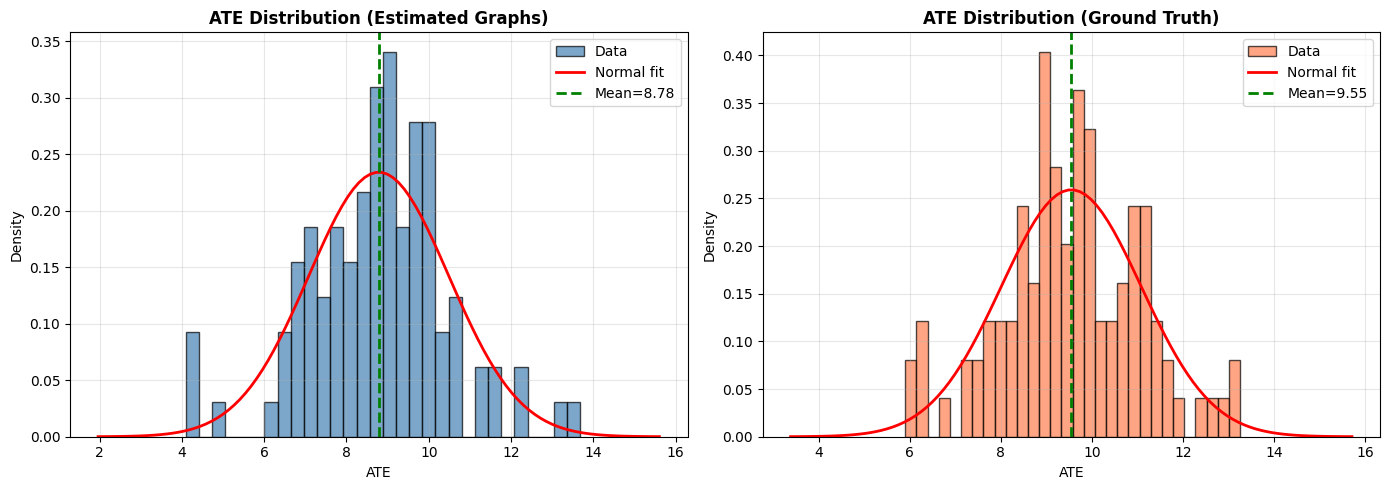

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Selected graphs distribution
mu_sel, sigma_sel = np.mean(ate_selected_array), np.std(ate_selected_array, ddof=1)
axes[0].hist(ate_selected_array, bins=30, density=True, alpha=0.7, 
            color='steelblue', edgecolor='black', label='Data')
x_sel = np.linspace(mu_sel - 4*sigma_sel, mu_sel + 4*sigma_sel, 100)
axes[0].plot(x_sel, stats.norm.pdf(x_sel, mu_sel, sigma_sel), 'r-', lw=2, label='Normal fit')
axes[0].axvline(mu_sel, color='green', linestyle='--', lw=2, label=f'Mean={mu_sel:.2f}')
axes[0].set_title('ATE Distribution (Estimated Graphs)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('ATE')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Ground truth distribution
mu_gt, sigma_gt = np.mean(ate_gt_array), np.std(ate_gt_array, ddof=1)
axes[1].hist(ate_gt_array, bins=30, density=True, alpha=0.7, 
            color='coral', edgecolor='black', label='Data')
x_gt = np.linspace(mu_gt - 4*sigma_gt, mu_gt + 4*sigma_gt, 100)
axes[1].plot(x_gt, stats.norm.pdf(x_gt, mu_gt, sigma_gt), 'r-', lw=2, label='Normal fit')
axes[1].axvline(mu_gt, color='green', linestyle='--', lw=2, label=f'Mean={mu_gt:.2f}')
axes[1].set_title('ATE Distribution (Ground Truth)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ATE')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Intervention in bmi and seeing diabetes mellitus outcome

coverage con bootstrapping

 en gaussiana media normal +- 3sigma
queremos ver donde donde caen las muestras este intervalo es distinro a la media

covergae gaussiana y coverage bootstraping las dos 
establecer una variable objetivo e ir interviniendo en todas
vector 1 o 0  si cae o no cae el valor dentro del intervalo


wilkockson mann-wiltney-U